# **Data Practicum**

**Network Modelling of Supply Chain Gaps that are Driven by Business Closures in the US**

### Week 4: Temporal Modeling

LSTM

In [ ]:
# Loading the merged dataset and inspect its structure
import pandas as pd
from pathlib import Path

df = pd.read_csv("df_merged.csv")

orig_shape = df.shape

# Filtering for year > 1999
numeric = pd.to_numeric(df['year'], errors='coerce')
year_int = numeric.where((numeric >= 1900) & (numeric <= 2100)).astype('Int64')
df['year'] = year_int
df = df[df['year'].notna() & (df['year'] > 1999)].copy()

# Converting to datetime for downstream operations
df['year'] = pd.to_datetime(df['year'].astype(int).astype(str) + '-01-01')

print(f"Original shape: {orig_shape}, after filtering year > 1999: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()


Original shape: (470989, 33), after filtering year > 1999: (245779, 33)
Columns: ['Unnamed: 0', 'year', 'st', 'sector', 'fage', 'firms', 'estabs', 'emp', 'denom', 'estabs_entry', 'estabs_entry_rate', 'estabs_exit', 'estabs_exit_rate', 'job_creation', 'job_creation_births', 'job_creation_continuers', 'job_creation_rate_births', 'job_creation_rate', 'job_destruction', 'job_destruction_deaths', 'job_destruction_continuers', 'job_destruction_rate_deaths', 'job_destruction_rate', 'net_job_creation', 'net_job_creation_rate', 'reallocation_rate', 'firmdeath_firms', 'firmdeath_estabs', 'firmdeath_emp', 'sector_name', 'state_abbr', 'income', 'population']


,Unnamed: 0,year,st,sector,fage,firms,estabs,emp,denom,estabs_entry,...,net_job_creation,net_job_creation_rate,reallocation_rate,firmdeath_firms,firmdeath_estabs,firmdeath_emp,sector_name,state_abbr,income,population
22,22,2000-01-01,1,11,b) 1,45.0,45.0,290.0,347.0,0.0,...,-113.0,-32.564841,32.276657,18.0,18.0,151.0,"Agriculture, Forestry, Fishing and Hunting",AL,60570.0,4452.173
23,23,2001-01-01,1,11,b) 1,48.0,48.0,345.0,367.0,0.0,...,-44.0,-11.989101,25.068120,16.0,16.0,60.0,"Agriculture, Forestry, Fishing and Hunting",AL,58790.0,4467.634
24,24,2002-01-01,1,11,b) 1,30.0,31.0,108.0,115.0,0.0,...,-16.0,-13.913043,29.565217,4.0,4.0,11.0,"Agriculture, Forestry, Fishing and Hunting",AL,62100.0,4480.089
25,25,2003-01-01,1,11,b) 1,34.0,34.0,208.0,231.0,0.0,...,-46.0,-19.913420,30.303030,8.0,8.0,20.0,"Agriculture, Forestry, Fishing and Hunting",AL,60270.0,4503.491
26,26,2004-01-01,1,11,b) 1,28.0,28.0,108.0,112.0,0.0,...,-6.0,-5.357143,55.357143,9.0,9.0,23.0,"Agriculture, Forestry, Fishing and Hunting",AL,57810.0,4530.729


In [ ]:
# Checking Missing Values
print("\nMissing values per column (only columns with missing data):")
missing = df.isna().sum()
print(missing[missing > 0])


Missing values per column (only columns with missing data):
Series([], dtype: int64)


# Feature Engineering for Temporal LSTM: Business Closure Prediction by Sector

Temporal features focused on **sector-level business closures** that drive supply chain gaps. The metrics relate to firm and establishment deaths, labor market dynamics, and growth momentum—all grouped by sector and state to preserve the panel structure critical for supply chain analysis.

In [ ]:
# Defining closure targets and core metrics
import numpy as np

df = df.copy()

# Primary closure targets
df['closure_target'] = df['firmdeath_firms']  # Direct target for LSTM
df['closure_rate'] = df['firmdeath_estabs'] / df['estabs']  # Normalized establishment death rate
df['closure_rate_firms'] = df['firmdeath_firms'] / df['firms']  # Normalized firm death rate

# Labor market stress and density indicators
df['employment_density'] = df['emp'] / df['population']
df['job_destruction_intensity'] = df['job_destruction'] / df['emp']

# Sorting by panel structure: sector and state
group_cols = ['state_abbr', 'sector_name']
df = df.sort_values(group_cols + ['year'])

print("Closure targets and core metrics created:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_target', 'closure_rate',
          'job_destruction_rate', 'employment_density']].head(10))


Closure targets and core metrics created:
      state_abbr                      sector_name       year  closure_target  \
17855         AK  Accommodation and Food Services 2000-01-01            39.0   
17901         AK  Accommodation and Food Services 2000-01-01            14.0   
17947         AK  Accommodation and Food Services 2000-01-01            14.0   
17993         AK  Accommodation and Food Services 2000-01-01             8.0   
18039         AK  Accommodation and Food Services 2000-01-01             6.0   
18085         AK  Accommodation and Food Services 2000-01-01            12.0   
18131         AK  Accommodation and Food Services 2000-01-01            15.0   
18177         AK  Accommodation and Food Services 2000-01-01             6.0   
18223         AK  Accommodation and Food Services 2000-01-01             3.0   
18269         AK  Accommodation and Food Services 2000-01-01             0.0   

       closure_rate  job_destruction_rate  employment_density  
17855      0.

In [ ]:
# Engineer temporal lag features by sector
# Lagged features capture historical dependencies critical for LSTM sequence modeling

lag_features = ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
group_cols = ['state_abbr', 'sector_name']

for col in lag_features:
    for lag in [1, 2]:
        df[f'lag{lag}_{col}'] = df.groupby(group_cols)[col].shift(lag)

print(f"Lagged features created for {lag_features}")
print(f"Total lag features: {len(lag_features) * 2}")
print("\nSample lagged features:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_rate', 'lag1_closure_rate',
          'lag2_closure_rate', 'job_destruction_rate', 'lag1_job_destruction_rate']].head(15))


Lagged features created for ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
Total lag features: 8

Sample lagged features:
      state_abbr                      sector_name       year  closure_rate  \
17855         AK  Accommodation and Food Services 2000-01-01      0.402062   
17901         AK  Accommodation and Food Services 2000-01-01      0.194444   
17947         AK  Accommodation and Food Services 2000-01-01      0.177215   
17993         AK  Accommodation and Food Services 2000-01-01      0.097561   
18039         AK  Accommodation and Food Services 2000-01-01      0.076923   
18085         AK  Accommodation and Food Services 2000-01-01      0.053571   
18131         AK  Accommodation and Food Services 2000-01-01      0.087156   
18177         AK  Accommodation and Food Services 2000-01-01      0.040541   
18223         AK  Accommodation and Food Services 2000-01-01      0.029703   
18269         AK  Accommodation and Food Services 2000-01-

In [ ]:
# Engineer derived features: moving averages and growth rates by sector
# These capture momentum and cyclical patterns in closure risk within sectors

# 3-year rolling averages smooth short-term volatility and reveal trends
df['ma3_closure_rate'] = df.groupby(group_cols)['closure_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df['ma3_job_destruction_rate'] = df.groupby(group_cols)['job_destruction_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# Year-over-year growth rates capture macro and sector momentum
df['income_yoy'] = df.groupby(group_cols)['income'].pct_change()
df['population_yoy'] = df.groupby(group_cols)['population'].pct_change()
df['employment_yoy'] = df.groupby(group_cols)['emp'].pct_change()

print("Derived features created:")
print("  - 3-year moving average for closure_rate and job_destruction_rate")
print("  - Year-over-year growth rates: income, population, employment")
print("\nSample derived features by sector:")
sample_sector = df[df['sector_name'].str.contains('Retail', na=False)].drop_duplicates('year').head(10)
print(sample_sector[['sector_name', 'year', 'closure_rate', 'ma3_closure_rate',
                      'income_yoy', 'population_yoy', 'employment_yoy']].to_string())


Derived features created:
  - 3-year moving average for closure_rate and job_destruction_rate
  - Year-over-year growth rates: income, population, employment

Sample derived features by sector:
        sector_name       year  closure_rate  ma3_closure_rate  income_yoy  population_yoy  employment_yoy
12427  Retail Trade 2000-01-01      0.359551          0.359551         NaN             NaN             NaN
12428  Retail Trade 2001-01-01      0.333333          0.135643    0.061532        0.009158       -0.978255
12429  Retail Trade 2002-01-01      0.217822          0.098071   -0.091326        0.013607       -0.979359
12430  Retail Trade 2003-01-01      0.231405          0.106672   -0.037861        0.009461       -0.954680
12431  Retail Trade 2004-01-01      0.230769          0.098068    0.036251        0.016767       -0.978248
12432  Retail Trade 2005-01-01      0.346535          0.133296   -0.013464        0.011619       -0.974861
12433  Retail Trade 2006-01-01      0.345238          0.1

In [ ]:
# Preparing sequences for LSTM (builds `sequences`, `targets`, `sequence_metadata`)
# Skipping sequences containing NaNs (e.g., from lag features)
import numpy as np

# Ensuring standard names exist
sequence_length = globals().get('sequence_length', 5)
group_cols = ['state_abbr', 'sector_name']

# Features
desired_features = [
    'closure_rate', 'ma3_closure_rate', 'lag1_closure_rate', 'lag2_closure_rate',
    'job_destruction_rate', 'ma3_job_destruction_rate', 'lag1_job_destruction_rate', 'lag2_job_destruction_rate',
    'net_job_creation_rate', 'reallocation_rate', 'income', 'population', 'employment_density', 'income_yoy'
]

feature_cols = [c for c in desired_features if c in df.columns]

sequences = []
targets = []
sequence_metadata = []

for (st, sec), grp in df.groupby(group_cols):
    grp = grp.sort_values('year')
    vals = grp[feature_cols].values
    tgts = grp['closure_target'].values
    years = grp['year'].dt.year.values
    for i in range(len(grp) - sequence_length + 1):
        seq = vals[i:i+sequence_length]
        tgt = tgts[i+sequence_length-1]
        tyear = years[i+sequence_length-1]
        # skip if any NaN in sequence or target
        if np.isnan(seq).any() or pd.isna(tgt):
            continue
        sequences.append(seq)
        targets.append(tgt)
        sequence_metadata.append({'state': st, 'sector': sec, 'start_year': int(years[i]), 'target_year': int(tyear)})

# Converting to arrays and dataframe
X = np.array(sequences)
y = np.array(targets)
metadata_df = pd.DataFrame(sequence_metadata)

print(f"Built sequences: {len(sequences)} (sequence_length={sequence_length}), feature_cols={len(feature_cols)}")


Built sequences: 240079 (sequence_length=5), feature_cols=14


In [ ]:
# Feature summary table and correlation analysis

feature_table = pd.DataFrame([
    ['closure_target', 'Firm deaths (count)', 'Primary LSTM target: actual business closures in sector'],
    ['closure_rate', 'Estab. deaths / Estabs', 'Normalized closure intensity by sector'],
    ['closure_rate_firms', 'Firm deaths / Firms', 'Firm-level closure intensity by sector'],
    ['job_destruction_rate', 'Job destruction rate', 'Labor market stress leading indicator'],
    ['net_job_creation_rate', 'Net job creation rate', 'Sector labor market momentum'],
    ['reallocation_rate', 'Reallocation rate', 'Structural churn within sector'],
    ['lag1_closure_rate', 'Previous-year closure rate', 'LSTM temporal dependency (t-1)'],
    ['lag2_closure_rate', 'Prior 2-year closure rate', 'LSTM temporal dependency (t-2)'],
    ['ma3_closure_rate', '3-year MA of closure rate', 'Smoothed trend in sector closures'],
    ['income', 'Median income', 'Proxy for local demand in sector'],
    ['population', 'Population', 'Market size and labor pool'],
    ['income_yoy', 'Income growth (YoY)', 'Demand momentum by sector'],
    ['population_yoy', 'Population growth (YoY)', 'Demographic momentum'],
    ['employment_density', 'Employment / population', 'Sector concentration in local area'],
], columns=['feature', 'definition', 'supply chain relevance'])

print("Selected Features for Sector-Level Closure Prediction:")
display(feature_table)

# Correlation analysis
corr_cols = ['closure_target', 'closure_rate', 'closure_rate_firms', 'job_destruction_rate',
             'net_job_creation_rate', 'reallocation_rate', 'income', 'population',
             'income_yoy', 'population_yoy', 'employment_density']
corr_matrix = df[corr_cols].corr().round(3)

print("\n\nCorrelation Matrix - Closure Predictors:")
display(corr_matrix)


Selected Features for Sector-Level Closure Prediction:


,feature,definition,supply chain relevance
0,closure_target,Firm deaths (count),Primary LSTM target: actual business closures ...
1,closure_rate,Estab. deaths / Estabs,Normalized closure intensity by sector
2,closure_rate_firms,Firm deaths / Firms,Firm-level closure intensity by sector
3,job_destruction_rate,Job destruction rate,Labor market stress leading indicator
4,net_job_creation_rate,Net job creation rate,Sector labor market momentum
5,reallocation_rate,Reallocation rate,Structural churn within sector
6,lag1_closure_rate,Previous-year closure rate,LSTM temporal dependency (t-1)
7,lag2_closure_rate,Prior 2-year closure rate,LSTM temporal dependency (t-2)
8,ma3_closure_rate,3-year MA of closure rate,Smoothed trend in sector closures
9,income,Median income,Proxy for local demand in sector




Correlation Matrix - Closure Predictors:


,closure_target,closure_rate,closure_rate_firms,job_destruction_rate,net_job_creation_rate,reallocation_rate,income,population,income_yoy,population_yoy,employment_density
closure_target,1.000,0.175,0.179,0.036,-0.009,0.234,0.038,0.526,0.012,0.135,0.078
closure_rate,0.175,1.000,0.993,0.234,-0.119,0.455,-0.030,0.030,0.050,0.346,-0.209
closure_rate_firms,0.179,0.993,1.000,0.230,-0.118,0.454,-0.032,0.038,0.048,0.344,-0.177
job_destruction_rate,0.036,0.234,0.230,1.000,-0.892,0.233,-0.016,0.008,0.011,0.088,-0.085
net_job_creation_rate,-0.009,-0.119,-0.118,-0.892,1.000,0.009,0.016,0.005,0.007,-0.004,0.021
reallocation_rate,0.234,0.455,0.454,0.233,0.009,1.000,-0.030,0.109,0.039,0.245,-0.125
income,0.038,-0.030,-0.032,-0.016,0.016,-0.030,1.000,0.057,0.058,0.007,0.027
population,0.526,0.030,0.038,0.008,0.005,0.109,0.057,1.000,-0.002,0.004,-0.006
income_yoy,0.012,0.050,0.048,0.011,0.007,0.039,0.058,-0.002,1.000,0.083,-0.015
population_yoy,0.135,0.346,0.344,0.088,-0.004,0.245,0.007,0.004,0.083,1.000,-0.072


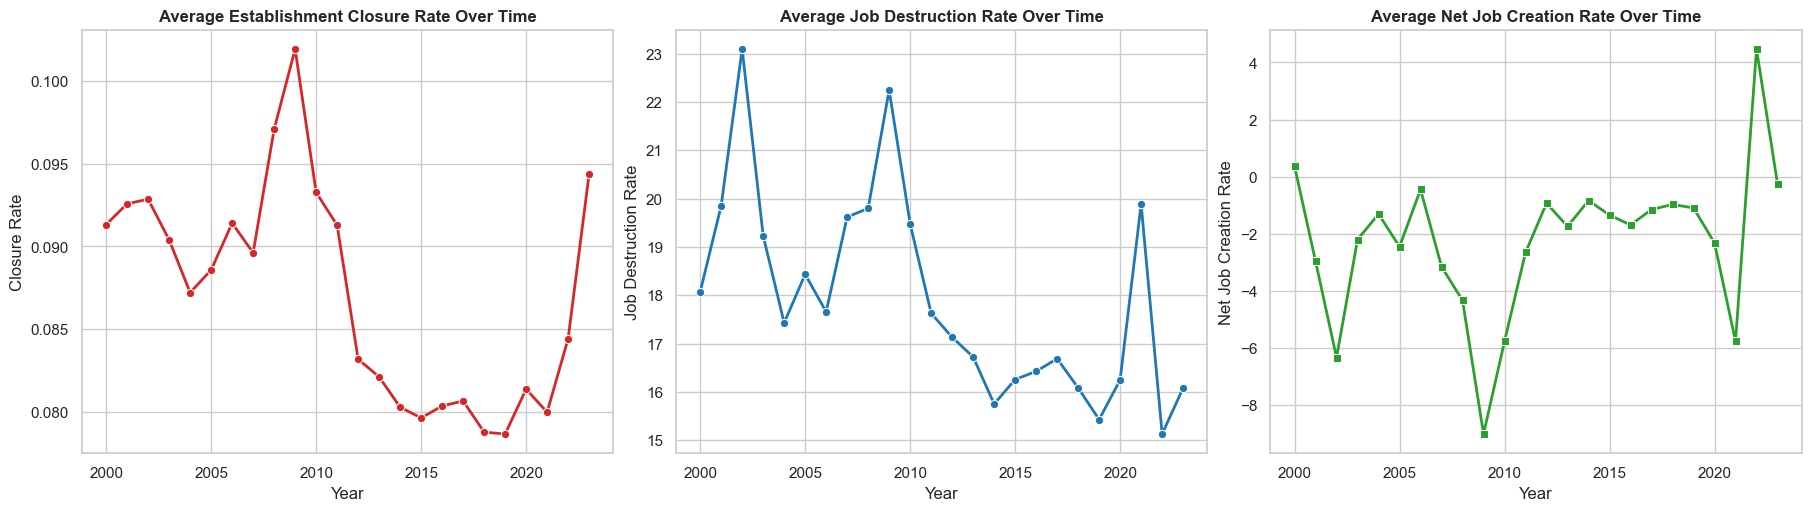

In [ ]:
# Visualizing temporal trends in business closures
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font_scale=1.0)

# Annual aggregate trends across all sectors
annual = df.groupby(df['year'].dt.year).agg(
    avg_closure_rate=('closure_rate', 'mean'),
    avg_job_destruction_rate=('job_destruction_rate', 'mean'),
    avg_net_job_creation_rate=('net_job_creation_rate', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

sns.lineplot(data=annual, x='year', y='avg_closure_rate', marker='o', ax=axes[0], color='#d62728', linewidth=2)
axes[0].set_title('Average Establishment Closure Rate Over Time', fontweight='bold')
axes[0].set_ylabel('Closure Rate')
axes[0].set_xlabel('Year')

sns.lineplot(data=annual, x='year', y='avg_job_destruction_rate', marker='o', ax=axes[1], color='#1f77b4', linewidth=2)
axes[1].set_title('Average Job Destruction Rate Over Time', fontweight='bold')
axes[1].set_ylabel('Job Destruction Rate')
axes[1].set_xlabel('Year')

sns.lineplot(data=annual, x='year', y='avg_net_job_creation_rate', marker='s', ax=axes[2], color='#2ca02c', linewidth=2)
axes[2].set_title('Average Net Job Creation Rate Over Time', fontweight='bold')
axes[2].set_ylabel('Net Job Creation Rate')
axes[2].set_xlabel('Year')

plt.show()


TOP SECTORS BY AVERAGE CLOSURE RATE (Supply Chain Vulnerability):
                                                    avg_closure_rate  \
sector_name                                                            
Transportation and Warehousing                                 0.117   
Arts, Entertainment, and Recreation                            0.105   
Information                                                    0.103   
Construction                                                   0.103   
Agriculture, Forestry, Fishing and Hunting                     0.102   
Administrative and Support and Waste Management...             0.100   
Accommodation and Food Services                                0.098   
Retail Trade                                                   0.097   
Real Estate and Rental and Leasing                             0.096   
Professional, Scientific, and Technical Services               0.091   
Wholesale Trade                                                0.089  

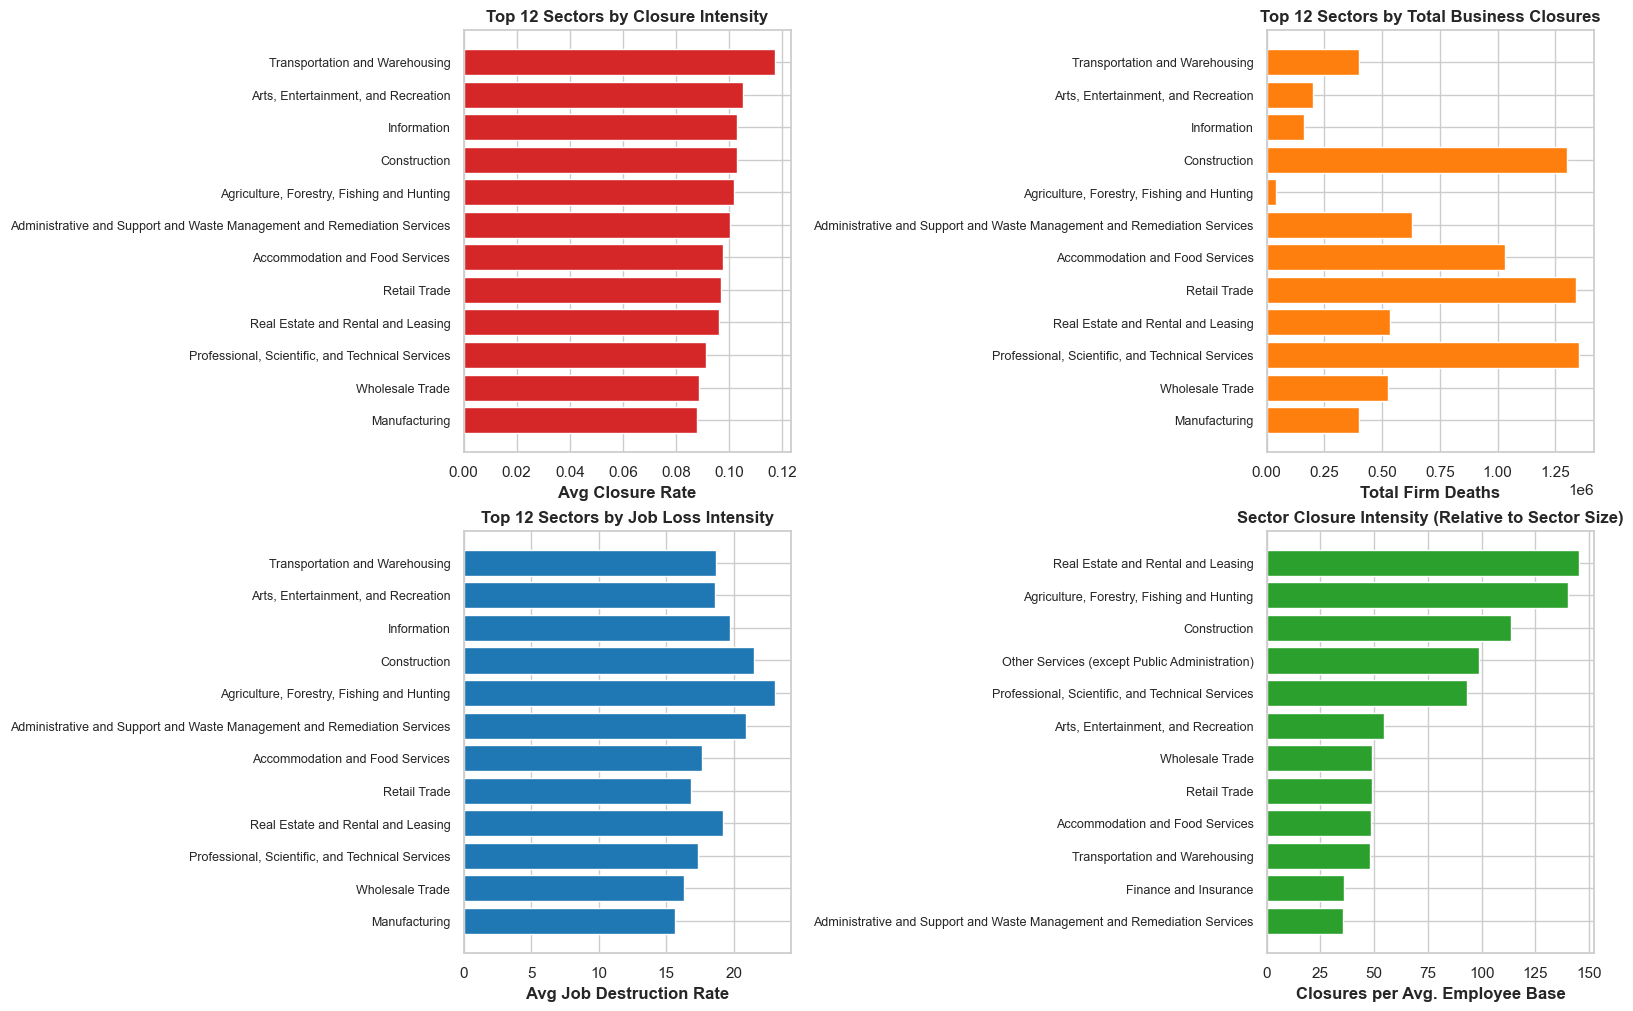

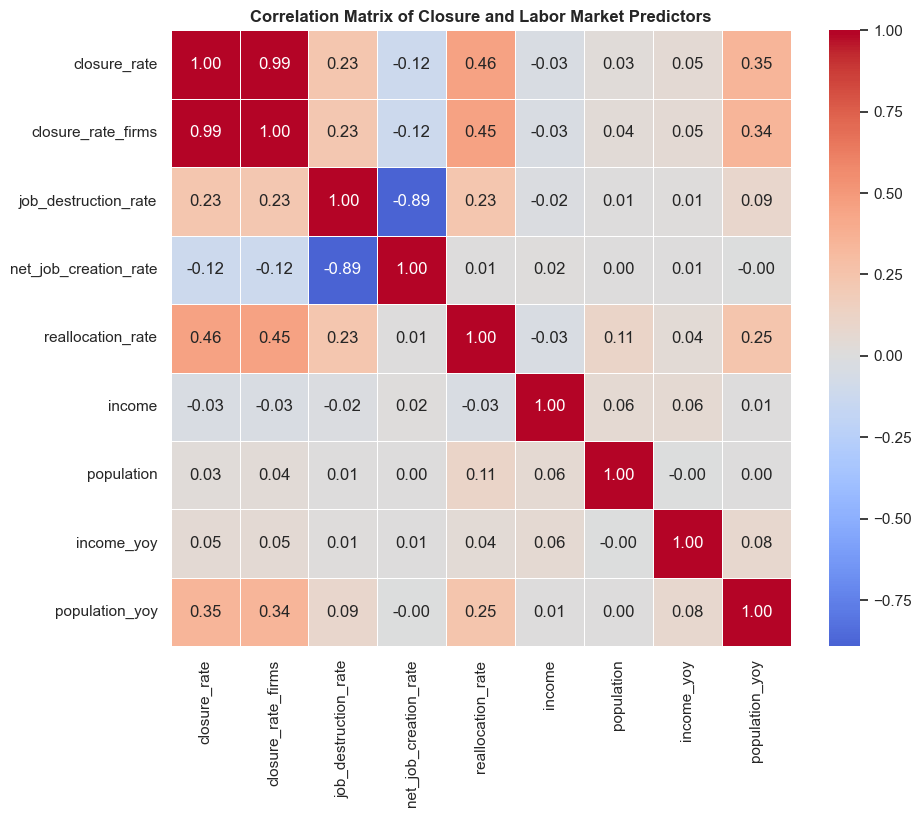

In [ ]:
# Sector-level closure analysis: supply chain vulnerability assessment
# Analyzing which sectors drive business closures and supply chain gaps

# Sector rankings by closure intensity
sector_summary = df.groupby('sector_name').agg(
    avg_closure_rate=('closure_rate', 'mean'),
    total_firms_deaths=('firmdeath_firms', 'sum'),
    avg_job_destruction_rate=('job_destruction_rate', 'mean'),
    avg_income=('income', 'mean'),
    avg_employment=('emp', 'mean')
).sort_values('avg_closure_rate', ascending=False)

print("TOP SECTORS BY AVERAGE CLOSURE RATE (Supply Chain Vulnerability):")
print(sector_summary.head(15).round(3))

# Visualizing sector closure vulnerability
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

top_sectors = sector_summary.head(12)
axes[0, 0].barh(range(len(top_sectors)), top_sectors['avg_closure_rate'].values, color='#d62728')
axes[0, 0].set_yticks(range(len(top_sectors)))
axes[0, 0].set_yticklabels(top_sectors.index, fontsize=9)
axes[0, 0].set_xlabel('Avg Closure Rate', fontweight='bold')
axes[0, 0].set_title('Top 12 Sectors by Closure Intensity', fontweight='bold')
axes[0, 0].invert_yaxis()

axes[0, 1].barh(range(len(top_sectors)), top_sectors['total_firms_deaths'].values, color='#ff7f0e')
axes[0, 1].set_yticks(range(len(top_sectors)))
axes[0, 1].set_yticklabels(top_sectors.index, fontsize=9)
axes[0, 1].set_xlabel('Total Firm Deaths', fontweight='bold')
axes[0, 1].set_title('Top 12 Sectors by Total Business Closures', fontweight='bold')
axes[0, 1].invert_yaxis()

axes[1, 0].barh(range(len(top_sectors)), top_sectors['avg_job_destruction_rate'].values, color='#1f77b4')
axes[1, 0].set_yticks(range(len(top_sectors)))
axes[1, 0].set_yticklabels(top_sectors.index, fontsize=9)
axes[1, 0].set_xlabel('Avg Job Destruction Rate', fontweight='bold')
axes[1, 0].set_title('Top 12 Sectors by Job Loss Intensity', fontweight='bold')
axes[1, 0].invert_yaxis()

sector_emp_closure = (sector_summary['total_firms_deaths'] / sector_summary['avg_employment']).sort_values(ascending=False).head(12)
axes[1, 1].barh(range(len(sector_emp_closure)), sector_emp_closure.values, color='#2ca02c')
axes[1, 1].set_yticks(range(len(sector_emp_closure)))
axes[1, 1].set_yticklabels(sector_emp_closure.index, fontsize=9)
axes[1, 1].set_xlabel('Closures per Avg. Employee Base', fontweight='bold')
axes[1, 1].set_title('Sector Closure Intensity (Relative to Sector Size)', fontweight='bold')
axes[1, 1].invert_yaxis()

plt.show()

# Correlation heatmap
corr_cols = ['closure_rate', 'closure_rate_firms', 'job_destruction_rate',
             'net_job_creation_rate', 'reallocation_rate', 'income', 'population',
             'income_yoy', 'population_yoy']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=.5, ax=ax)
ax.set_title('Correlation Matrix of Closure and Labor Market Predictors', fontweight='bold')
plt.show()


In [ ]:
# Ensuring variables exist when running this cell standalone
import pandas as pd
import numpy as np

# Building arrays from prepared lists
X = np.array(sequences)
y = np.array(targets)
metadata_df = pd.DataFrame(sequence_metadata)

# Correctly compute unique counts and group sizes
n_states = metadata_df['state'].nunique() if not metadata_df.empty else 0
n_sectors = metadata_df['sector'].nunique() if not metadata_df.empty else 0
n_groups = metadata_df.groupby(['state', 'sector']).ngroups if not metadata_df.empty else 0
mean_sequences_per_group = (len(sequences) / n_groups) if n_groups > 0 else 0

print(f"Sequence dataset shape: X={X.shape}, y={y.shape}")
print(f"Number of unique states: {n_states}, unique sectors: {n_sectors}, total sector-state groups: {n_groups}")
print(f"Number of sequences per sector-state group (mean): {mean_sequences_per_group:.1f}")
print(f"\nFeatures used: {len(feature_cols)}")
print(f"Sequence length (temporal window): {sequence_length} years")

if y.size > 0:
    print("\nTarget variable distribution (closure_target):")
    print(f"  Mean: {y.mean():.2f}")
    print(f"  Std:  {y.std():.2f}")
    print(f"  Min:  {y.min():.2f}")
    print(f"  Max:  {y.max():.2f}")
else:
    print("\nNo target values available (y is empty)")


Sequence dataset shape: X=(240079, 5, 14), y=(240079,)
Number of unique states: 50, unique sectors: 19, total sector-state groups: 950
Number of sequences per sector-state group (mean): 252.7

Features used: 14
Sequence length (temporal window): 5 years

Target variable distribution (closure_target):
  Mean: 41.63
  Std:  89.68
  Min:  0.00
  Max:  2619.00


In [ ]:
# Scaling features and prepare train/test split
# Preserving temporal structure: train on earlier years, test on recent years

# Scaling features while respecting temporal shape
n_samples, seq_len, n_features = X.shape
X_flat = X.reshape(-1, n_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(n_samples, seq_len, n_features)

# Splitting by time: training on earlier years, testing on recent years to avoid data leakage
train_cutoff_year = metadata_df['target_year'].quantile(0.8)
train_idx = metadata_df['target_year'] <= train_cutoff_year
test_idx = metadata_df['target_year'] > train_cutoff_year

X_train = X_scaled[train_idx]
X_test = X_scaled[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Train/Test Split (Temporal Stratification):")
print(f"  Training cutoff year: {train_cutoff_year:.0f}")
print(f"  Train set size: {X_train.shape[0]} sequences ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"  Test set size:  {X_test.shape[0]} sequences ({X_test.shape[0] / len(X) * 100:.1f}%)")
print(f"\nTrain target distribution:")
print(f"  Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"Test target distribution:")
print(f"  Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")


Train/Test Split (Temporal Stratification):
  Training cutoff year: 2019
  Train set size: 199281 sequences (83.0%)
  Test set size:  40798 sequences (17.0%)

Train target distribution:
  Mean: 41.01, Std: 87.56
Test target distribution:
  Mean: 44.65, Std: 99.34


c:\Users\USER\miniconda3\envs\notebook_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Model Architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 5, 64)          │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)

None

Training LSTM model for sector-level closure prediction...
Epoch 1/30
6228/6228 ━━━━━━━━━━━━━━━━━━━━ 76s 11ms/step - loss: 2608.7415 - mae: 19.0772 - val_loss: 2764.7839 - val_mae: 18.3548
Epoch 2/30
6228/6228 ━━━━━━━━━━━━━━━━━━━━ 66s 11ms/step - loss: 1368.2120 - mae: 15.1153 - val_loss: 2568.3142 - val_mae: 16.9449
Epoch 3/30
6228/6228 ━━━━━━━━━━━━━━━━━━━━ 59s 10ms/step - loss: 1199.3279 - mae: 14.1637 - val_loss: 2504.1787 - val_mae: 16.5923
Epoch 4/30
6228/6228 ━━━━━━━━━━━━━━━━━━━━ 69s 11ms/step - loss: 1104.6250 - mae: 13.6410 - val_loss: 2159.0232 - val_mae: 15.5892
Epoch 5/30
6228/6228 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - loss: 1028.1359 - mae: 13.2230 - val_loss: 2255.6609 - val_mae: 15.8535
Epoch 6/30
6228/6228 ━━━━━━━━━━━━━━━━━━━━ 60s 10ms/step - loss: 970.0083 - mae: 12.9131 - val_loss: 2173.3162 - val_mae: 15.7711
Epoch 7/30
6228/6228 ━━━━━━━━━━━━━━━━━━━━ 57s 9ms/step - loss: 920.8711 - mae: 12.6987 - val_loss: 2002.3721 - val_mae: 15.2613
Epoch 8/30
6228/6228 ━━━━━━━

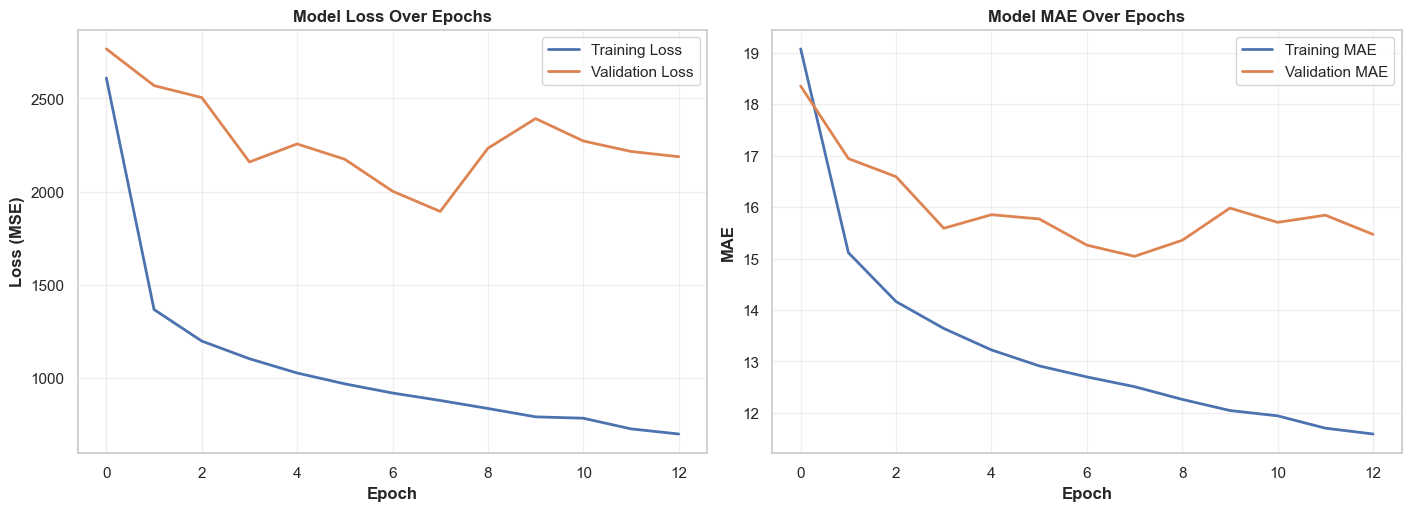

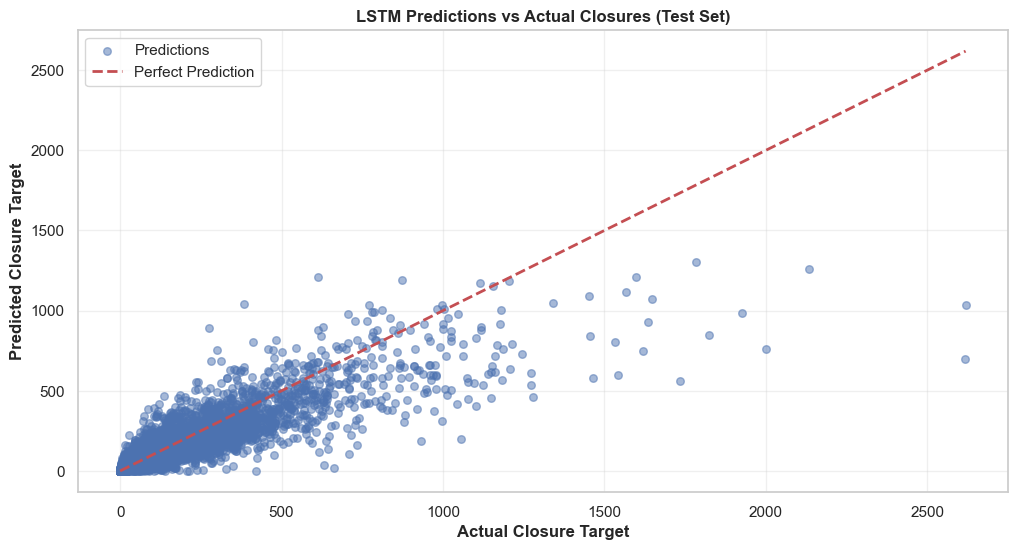

In [ ]:
# Building and training LSTM model for sector-level closure prediction

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Defining LSTM architecture
model = Sequential([
    LSTM(64, input_shape=(sequence_length, n_features), return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # Output: closure_target prediction
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("LSTM Model Architecture:")
print(model.summary())

# Training with early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nTraining LSTM model for sector-level closure prediction...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluating on test set
y_pred_train = model.predict(X_train, verbose=0).flatten()
y_pred_test = model.predict(X_test, verbose=0).flatten()

train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f"\nModel Performance on Sector-Level Closure Prediction:")
print(f"{'Metric':<15} {'Train':<15} {'Test':<15}")
print("-" * 45)
print(f"{'MSE':<15} {train_mse:<15.4f} {test_mse:<15.4f}")
print(f"{'RMSE':<15} {train_rmse:<15.4f} {test_rmse:<15.4f}")
print(f"{'MAE':<15} {train_mae:<15.4f} {test_mae:<15.4f}")
print(f"{'R2':<15} {train_r2:<15.4f} {test_r2:<15.4f}")

# Plotting training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontweight='bold')
axes[0].set_title('Model Loss Over Epochs', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('MAE', fontweight='bold')
axes[1].set_title('Model MAE Over Epochs', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.show()

# Prediction vs actual comparison
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(y_test, y_pred_test, alpha=0.5, s=30, label='Predictions')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Closure Target', fontweight='bold')
ax.set_ylabel('Predicted Closure Target', fontweight='bold')
ax.set_title('LSTM Predictions vs Actual Closures (Test Set)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()
